# HealthBench Dataset Exploration

Complete walkthrough of the HealthBench benchmark using the registered analysis functions.

**Subsets**
| Subset | Size | Notes |
|---|---|---|
| `main` | 5,000 | General difficulty |
| `hard` | 1,000 | Max model score ~32% |
| `consensus` | 3,671 | Physician-validated |

**Analysis categories** (23 registered functions)
- `exploration` — 12 descriptive stats functions
- `insights` — 8 cross-dimensional functions
- `visualization` — 3 figure-producing functions

## Setup

In [1]:
import logging
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from healthbench_agent.analysis import run_category, run_one
from healthbench_agent.analysis.registry import _analysis_registry
from healthbench_agent.dataset.loader import load_dataset

logging.basicConfig(level=logging.WARNING)

OUTPUT_DIR = Path("exports")
OUTPUT_DIR.mkdir(exist_ok=True)

for cat in ["exploration", "insights", "visualization"]:
    names = [n for n, e in _analysis_registry.items() if e.category == cat]
    print(f"{cat} ({len(names)}): {names}")

exploration (12): ['sample_counts', 'prompt_structure', 'rubric_size', 'rubric_points_distribution', 'positive_vs_penalty_stats', 'score_range_stats', 'rubric_tag_frequency', 'rubric_tags_per_sample', 'example_tag_frequency', 'tag_prefix_distribution', 'data_quality', 'subset_overlap']
insights (8): ['theme_axis_breakdown', 'rubric_axis_difficulty', 'penalty_concentration', 'criterion_text_length_stats', 'score_ceiling_by_theme', 'emergency_axis_profile', 'hard_subset_signature', 'prompt_length_vs_rubric_complexity']
visualization (6): ['score_ceiling_distribution', 'theme_axis_heatmap', 'criteria_weight_histogram', 'penalty_heatmap', 'multiturn_complexity_comparison', 'penalty_ratio_cdf']


## 1. Load Datasets

In [2]:
main = load_dataset("main")
hard = load_dataset("hard")
consensus = load_dataset("consensus")
datasets = [main, hard, consensus]

for ds in datasets:
    print(f"{ds.subset:10} {len(ds.samples):,} samples")

main       5,000 samples
hard       1,000 samples
consensus  3,671 samples


In [11]:
pd.DataFrame(
    [
        {"last_role": s.prompt[-1]["role"], "first_role": s.prompt[0]["role"]}
        for s in datasets[2].samples
    ]
).describe()

,last_role,first_role
count,3671,3671
unique,1,1
top,user,user
freq,3671,3671


In [12]:
pd.DataFrame(
    [
        {
            role: sum(1 for t in s.prompt if t["role"] == role)
            for role in ["user", "assistant", "system"]
        }
        for s in datasets[0].samples
    ]
).describe()

,user,assistant,system
count,5000.000000,5000.000000,5000.0
mean,1.806000,0.806000,0.0
std,1.216495,1.216495,0.0
min,1.000000,0.000000,0.0
25%,1.000000,0.000000,0.0
50%,1.000000,0.000000,0.0
75%,2.000000,1.000000,0.0
max,10.000000,9.000000,0.0


In [17]:
from healthbench_agent.analysis.utils import tag_value

rows = [
    {"axis": tag_value(r.tags, "axis"), "points": r.points}
    for s in datasets[0].samples
    for r in s.rubrics
]
df = pd.DataFrame(rows)
df.groupby("axis")["points"].agg(["mean", "sum", "min", "max", "count"]).sort_values("mean")

,mean,sum,min,max,count
axis,,,,,
communication_quality,1.307165,5911,-10,10,4522
instruction_following,1.735398,4427,-10,10,2551
accuracy,1.939591,36635,-10,10,18888
completeness,2.931299,65324,-10,10,22285
context_awareness,3.138805,28221,-10,10,8991


In [18]:
df_pos = df[df["points"] > 0].groupby("axis")["points"].sum()
df_total = df["points"].abs().groupby(df["axis"]).sum()
(df_pos / df_total).sort_values()

axis
communication_quality    0.630101
accuracy                 0.642685
instruction_following    0.648627
completeness             0.706795
context_awareness        0.746055
Name: points, dtype: float64

In [20]:
df_neg = df[df["points"] < 0].groupby("axis")["points"].sum()
df_total = df["points"].abs().groupby(df["axis"]).sum()
(df_neg / df_total).sort_values()

axis
communication_quality   -0.369899
accuracy                -0.357315
instruction_following   -0.351373
completeness            -0.293205
context_awareness       -0.253945
Name: points, dtype: float64

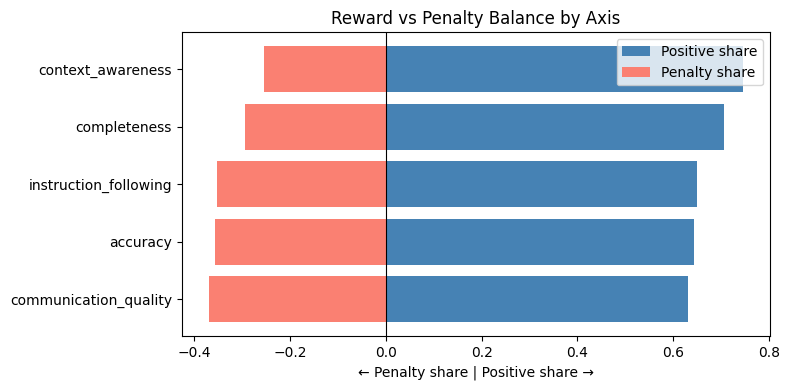

In [21]:
import matplotlib.pyplot as plt

pos_ratio = (df_pos / df_total).sort_values()
neg_ratio = 1 - pos_ratio

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(pos_ratio.index, pos_ratio, color="steelblue", label="Positive share")
ax.barh(pos_ratio.index, -neg_ratio, color="salmon", label="Penalty share")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("← Penalty share | Positive share →")
ax.set_title("Reward vs Penalty Balance by Axis")
ax.legend()
fig.tight_layout()

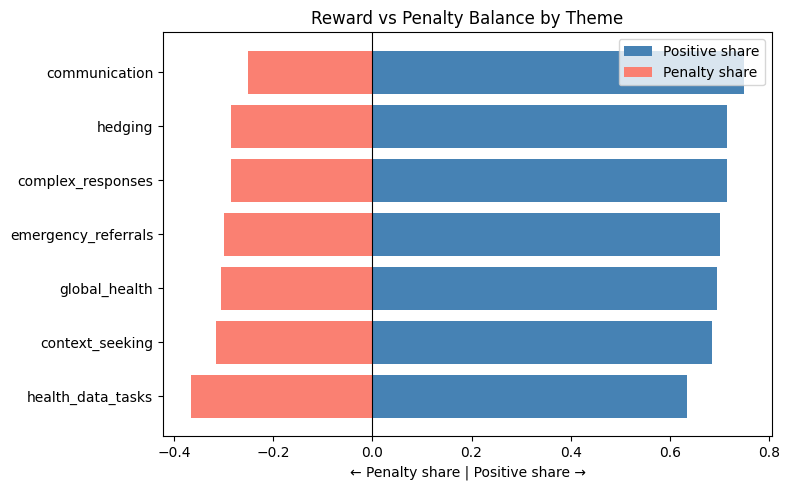

In [22]:
rows_theme = [
    {"theme": tag_value(s.example_tags, "theme") or "_unknown", "points": r.points}
    for ds in datasets
    for s in ds.samples
    for r in s.rubrics
]
df_theme = pd.DataFrame(rows_theme)

pos_theme = df_theme[df_theme["points"] > 0].groupby("theme")["points"].sum()
total_theme = df_theme["points"].abs().groupby(df_theme["theme"]).sum()
theme_ratio = (pos_theme / total_theme).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(theme_ratio.index, theme_ratio, color="steelblue", label="Positive share")
ax.barh(theme_ratio.index, -(1 - theme_ratio), color="salmon", label="Penalty share")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("← Penalty share | Positive share →")
ax.set_title("Reward vs Penalty Balance by Theme")
ax.legend()
fig.tight_layout()

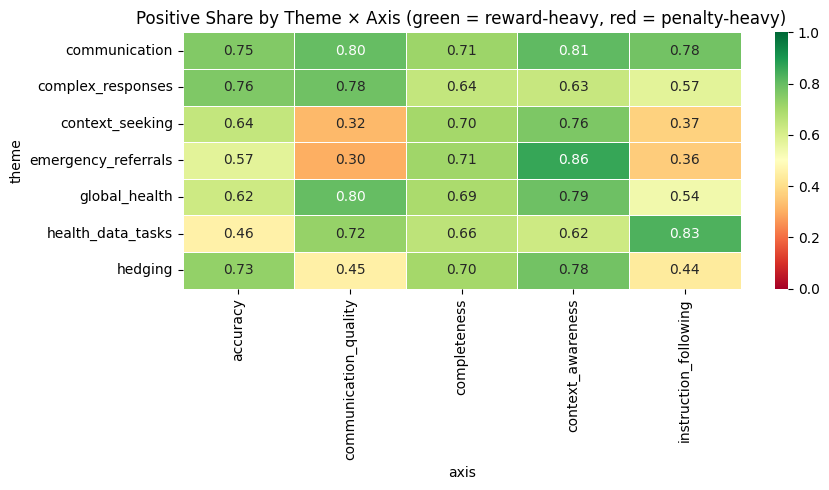

In [25]:
import seaborn as sns

rows_both = [
    {
        "theme": tag_value(s.example_tags, "theme") or "_unknown",
        "axis": tag_value(r.tags, "axis") or "_unknown",
        "points": r.points,
    }
    for ds in datasets
    for s in ds.samples
    for r in s.rubrics
]
df_both = pd.DataFrame(rows_both)

pivot = df_both.pivot_table(
    values="points",
    index="theme",
    columns="axis",
    aggfunc=lambda x: x[x > 0].sum() / x.abs().sum(),
).round(3)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0.5,
    vmin=0,
    vmax=1,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Positive Share by Theme × Axis (green = reward-heavy, red = penalty-heavy)")
fig.tight_layout()

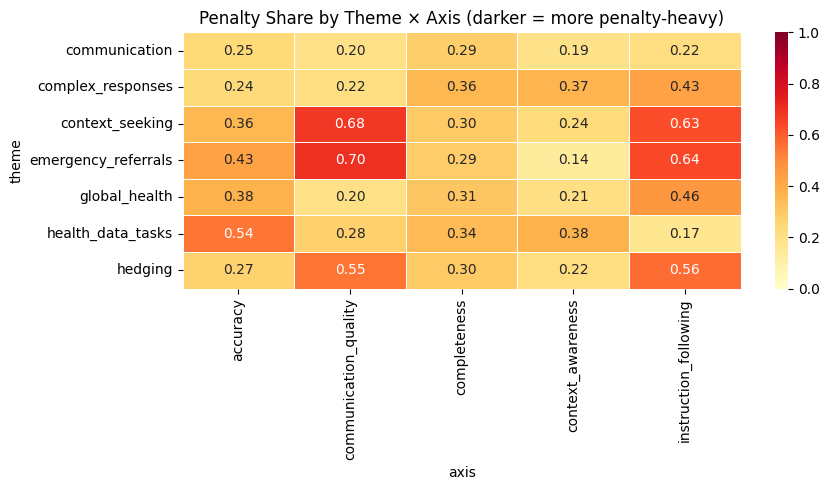

In [27]:
pivot_neg = df_both.pivot_table(
    values="points",
    index="theme",
    columns="axis",
    aggfunc=lambda x: abs(x[x < 0].sum()) / x.abs().sum() if x.abs().sum() > 0 else 0,
).round(3)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    pivot_neg,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Penalty Share by Theme × Axis (darker = more penalty-heavy)")
fig.tight_layout()

---
## 2. Dataset Overview
### 2.1 Sample Counts

In [8]:
result = run_one("sample_counts", datasets, OUTPUT_DIR)["sample_counts"]

rows = []
for subset, stats in result.items():
    if not stats:
        continue
    rows.append(
        {
            "subset": subset,
            "total_samples": stats["total_samples"],
            "unique_prompt_ids": stats["unique_prompt_ids"],
            "with_ideal_%": round(stats["with_ideal_completions_fraction"] * 100, 1),
            "physician_groups": len(stats.get("physician_group_distribution", {})),
        }
    )
display(pd.DataFrame(rows).set_index("subset"))

,total_samples,unique_prompt_ids,with_ideal_%,physician_groups
subset,,,,
main,5000,5000,84.1,3
hard,1000,1000,89.4,3
consensus,3671,3671,85.3,3


### 2.2 Prompt Structure

In [9]:
result = run_one("prompt_structure", datasets, OUTPUT_DIR)["prompt_structure"]

rows = []
for subset, stats in result.items():
    if not stats:
        continue
    rows.append(
        {
            "subset": subset,
            "single_turn": stats["single_turn_count"],
            "multi_turn": stats["multi_turn_count"],
            "mean_turns": round(stats["num_turns_stats"]["mean"], 2),
            "mean_chars": round(stats["total_char_length_stats"]["mean"], 0),
            "p95_chars": round(stats["total_char_length_stats"]["95%"], 0),
        }
    )
display(pd.DataFrame(rows).set_index("subset"))

,single_turn,multi_turn,mean_turns,mean_chars,p95_chars
subset,,,,,
main,2915,2085,2.61,668.0,2424.0
hard,523,477,2.82,707.0,2457.0
consensus,2201,1470,2.57,648.0,2370.0


### 2.3 Rubric Size

In [10]:
result = run_one("rubric_size", datasets, OUTPUT_DIR)["rubric_size"]

rows = []
for subset, stats in result.items():
    if not stats:
        continue
    s = stats["rubric_size_stats"]
    rows.append(
        {
            "subset": subset,
            "mean": round(s["mean"], 2),
            "min": int(s["min"]),
            "max": int(s["max"]),
            "p50": s["50%"],
            "p95": s["95%"],
        }
    )
display(pd.DataFrame(rows).set_index("subset"))

,mean,min,max,p50,p95
subset,,,,,
main,11.45,2,48,11.0,21.0
hard,11.85,2,40,11.0,22.0
consensus,2.19,2,3,2.0,3.0


---
## 3. Rubric Analysis
### 3.1 Points Distribution

In [11]:
result = run_one("rubric_points_distribution", datasets, OUTPUT_DIR)["rubric_points_distribution"]

rows = []
for subset, stats in result.items():
    if not stats:
        continue
    rows.append(
        {
            "subset": subset,
            "total_items": stats["total_rubric_items"],
            "positive_%": round(stats["fraction_positive"] * 100, 1),
            "negative_%": round(stats["fraction_negative"] * 100, 1),
            "zero_%": round(stats["fraction_zero"] * 100, 1),
            "mean_points": round(stats["points_stats"]["mean"], 2),
            "min_points": stats["points_stats"]["min"],
            "max_points": stats["points_stats"]["max"],
        }
    )
display(pd.DataFrame(rows).set_index("subset"))

,total_items,positive_%,negative_%,zero_%,mean_points,min_points,max_points
subset,,,,,,,
main,57237,69.3,30.7,0.0,2.46,-10.0,10.0
hard,11846,65.1,34.9,0.0,1.89,-10.0,10.0
consensus,8053,100.0,0.0,0.0,5.00,5.0,5.0


### 3.2 Positive vs Penalty Balance

In [12]:
result = run_one("positive_vs_penalty_stats", datasets, OUTPUT_DIR)["positive_vs_penalty_stats"]

rows = []
for subset, stats in result.items():
    if not stats:
        continue
    rows.append(
        {
            "subset": subset,
            "mean_possible_pts": round(stats["total_possible_points_stats"]["mean"], 2),
            "mean_penalty_pts": round(stats["total_penalty_points_stats"]["mean"], 2),
            "mean_penalty_ratio": round(stats["penalty_mass_ratio_stats"]["mean"], 3),
            "p95_penalty_ratio": round(stats["penalty_mass_ratio_stats"]["95%"], 3),
            "zero_possible_pts": stats["samples_with_zero_possible_points"],
        }
    )
display(pd.DataFrame(rows).set_index("subset"))

,mean_possible_pts,mean_penalty_pts,mean_penalty_ratio,p95_penalty_ratio,zero_possible_pts
subset,,,,,
main,52.18,24.08,0.495,1.087,0
hard,51.60,29.18,0.642,1.333,0
consensus,10.97,0.00,0.000,0.000,0


### 3.3 Score Range

In [13]:
result = run_one("score_range_stats", datasets, OUTPUT_DIR)["score_range_stats"]

rows = []
for subset, stats in result.items():
    if not stats:
        continue
    rows.append(
        {
            "subset": subset,
            "mean_max_score": round(stats["max_possible_score_stats"]["mean"], 2),
            "mean_min_score": round(stats["min_possible_score_stats"]["mean"], 2),
            "mean_range_width": round(stats["score_range_width_stats"]["mean"], 2),
            "p95_range_width": round(stats["score_range_width_stats"]["95%"], 2),
        }
    )
display(pd.DataFrame(rows).set_index("subset"))

,mean_max_score,mean_min_score,mean_range_width,p95_range_width
subset,,,,
main,52.18,-24.08,76.26,146.00
hard,51.60,-29.18,80.78,150.05
consensus,10.97,0.00,10.97,15.00


---
## 4. Tag Analysis
### 4.1 Tag Prefix Structure

In [14]:
result = run_one("tag_prefix_distribution", datasets, OUTPUT_DIR)["tag_prefix_distribution"]

for subset, stats in result.items():
    if not stats:
        continue
    print(f"\n{subset}")
    print(f"  example tag prefixes : {stats['example_tag_unique_prefixes']}")
    print(f"  rubric tag prefixes  : {stats['rubric_tag_unique_prefixes']}")
    for prefix, values in stats["example_tag_prefix_distribution"].items():
        top = dict(sorted(values.items(), key=lambda x: -x[1])[:6])
        print(f"  [{prefix}] {top}")


main
  example tag prefixes : ['_no_prefix']
  rubric tag prefixes  : ['_no_prefix']
  [_no_prefix] {'theme:global_health': 1097, 'theme:hedging': 1071, 'theme:communication': 919, 'theme:context_seeking': 594, 'theme:emergency_referrals': 482, 'theme:health_data_tasks': 477}

hard
  example tag prefixes : ['_no_prefix']
  rubric tag prefixes  : ['_no_prefix']
  [_no_prefix] {'theme:global_health': 280, 'theme:context_seeking': 179, 'theme:hedging': 167, 'theme:health_data_tasks': 115, 'theme:communication': 111, 'theme:complex_responses': 82}

consensus
  example tag prefixes : ['_no_prefix']
  rubric tag prefixes  : ['_no_prefix']
  [_no_prefix] {'theme:communication': 746, 'theme:hedging': 711, 'theme:global_health': 634, 'theme:emergency_referrals': 453, 'physician_agreed_category:not-health-professional': 424, 'theme:context_seeking': 408}


### 4.2 Rubric Tag Frequency

In [15]:
result = run_one("rubric_tag_frequency", datasets, OUTPUT_DIR)["rubric_tag_frequency"]

rows = []
for subset, stats in result.items():
    if not stats:
        continue
    rows.append(
        {
            "subset": subset,
            "unique_tags": stats["total_unique_tags"],
            "total_occurrences": stats["total_tag_occurrences"],
            "mean_tags_per_item": round(stats["mean_tags_per_rubric_item"], 2),
            "fraction_with_tag": round(stats["fraction_with_tag"], 3),
        }
    )
display(pd.DataFrame(rows).set_index("subset"))

,unique_tags,total_occurrences,mean_tags_per_item,fraction_with_tag
subset,,,,
main,44,122527,2.14,1.0
hard,44,24944,2.11,1.0
consensus,43,24159,3.00,1.0


### 4.3 Data Quality

In [16]:
result = run_one("data_quality", datasets, OUTPUT_DIR)["data_quality"]

rows = []
for subset, stats in result.items():
    if not stats:
        continue
    rows.append(
        {
            "subset": subset,
            "duplicate_prompt_ids": stats["duplicate_prompt_id_count"],
            "empty_rubrics": stats["empty_rubrics_count"],
            "zero_possible_pts": stats["zero_possible_points_samples_count"],
            "empty_rubric_tags_%": round(stats["empty_rubric_tags_fraction"] * 100, 1),
            "empty_example_tags_%": round(stats["empty_example_tags_fraction"] * 100, 1),
        }
    )
display(pd.DataFrame(rows).set_index("subset"))

,duplicate_prompt_ids,empty_rubrics,zero_possible_pts,empty_rubric_tags_%,empty_example_tags_%
subset,,,,,
main,0,0,0,0.0,0.0
hard,0,0,0,0.0,0.0
consensus,0,0,0,0.0,0.0


### 4.4 Subset Overlap (hard ∩ consensus)

In [17]:
result = run_one("subset_overlap", datasets, OUTPUT_DIR)["subset_overlap"]
display(pd.DataFrame([result]))

,hard_only_count,consensus_only_count,intersection_count,hard_total,consensus_total,jaccard_similarity
0,414,3085,586,1000,3671,0.143452


---
## 5. Cross-dimensional Insights
### 5.1 Theme × Axis Breakdown

In [18]:
result = run_one("theme_axis_breakdown", datasets, OUTPUT_DIR)["theme_axis_breakdown"]

for subset, stats in result.items():
    if not stats:
        continue
    print(
        f"\n{subset} — {stats['total_samples']} samples, "
        f"missing_theme={stats['missing_theme_count']}, "
        f"missing_axis={stats['missing_axis_count']}"
    )
    df = pd.DataFrame(stats["cross_table"]).T.fillna(0).astype(int)
    display(df)


main — 5000 samples, missing_theme=5000, missing_axis=5000


,_unknown
_unknown,5000



hard — 1000 samples, missing_theme=1000, missing_axis=1000


,_unknown
_unknown,1000



consensus — 3671 samples, missing_theme=3671, missing_axis=3671


,_unknown
_unknown,3671


### 5.2 Score Ceiling by Theme

In [19]:
result = run_one("score_ceiling_by_theme", datasets, OUTPUT_DIR)["score_ceiling_by_theme"]

for subset, stats in result.items():
    if not stats:
        continue
    df = pd.DataFrame(
        {
            "mean_possible_pts": stats["theme_mean_possible_points"],
            "mean_penalty_ratio": stats["theme_mean_penalty_ratio"],
            "sample_count": stats["theme_sample_counts"],
        }
    ).sort_values("mean_possible_pts", ascending=False)
    print(
        f"\n{subset} — overall_mean_possible={stats['overall_mean_possible_points']}, "
        f"overall_mean_penalty_ratio={stats['overall_mean_penalty_ratio']}"
    )
    display(df)


main — overall_mean_possible=52.1796, overall_mean_penalty_ratio=0.4951


,mean_possible_pts,mean_penalty_ratio,sample_count
_unknown,52.1796,0.4951,5000



hard — overall_mean_possible=51.599, overall_mean_penalty_ratio=0.6416


,mean_possible_pts,mean_penalty_ratio,sample_count
_unknown,51.599,0.6416,1000



consensus — overall_mean_possible=10.9684, overall_mean_penalty_ratio=0.0


,mean_possible_pts,mean_penalty_ratio,sample_count
_unknown,10.9684,0.0,3671


### 5.3 Emergency / Safety Profile

In [20]:
result = run_one("emergency_axis_profile", datasets, OUTPUT_DIR)["emergency_axis_profile"]

rows = []
for subset, stats in result.items():
    if not stats:
        continue
    rows.append(
        {
            "subset": subset,
            "emergency_items": stats["emergency_rubric_item_count"],
            "emergency_items_%": round(stats["emergency_rubric_item_fraction"] * 100, 1),
            "samples_with_emergency": stats["samples_with_emergency_item_count"],
            "samples_%": round(stats["samples_with_emergency_item_fraction"] * 100, 1),
            "penalty_total": stats["emergency_penalty_points_total"],
        }
    )
display(pd.DataFrame(rows).set_index("subset"))

# Theme breakdown for main
if result.get("main"):
    print("\nmain — emergency samples by theme:")
    display(
        pd.Series(result["main"]["theme_counts"]).sort_values(ascending=False).to_frame("count")
    )

,emergency_items,emergency_items_%,samples_with_emergency,samples_%,penalty_total
subset,,,,,
main,3838,6.7,1695,33.9,6335.0
hard,726,6.1,323,32.3,1424.0
consensus,1550,19.2,1142,31.1,0.0



main — emergency samples by theme:


,count
_unknown,1695


### 5.4 Hard Subset Signature (hard vs main)

In [21]:
result = run_one("hard_subset_signature", datasets, OUTPUT_DIR)["hard_subset_signature"]

if result:
    metrics = ["rubric_size", "total_possible_points", "penalty_mass_ratio", "prompt_char_length"]
    comparison = pd.DataFrame(
        {
            "main": {m: result["main_stats"][m] for m in metrics},
            "hard": {m: result["hard_stats"][m] for m in metrics},
            "delta": result["delta"],
        }
    )
    display(comparison)

    theme_df = (
        pd.DataFrame(
            {
                "main": result["theme_distribution_main"],
                "hard": result["theme_distribution_hard"],
            }
        )
        .fillna(0)
        .astype(int)
        .sort_values("main", ascending=False)
    )
    print("\nTheme distribution:")
    display(theme_df)

,main,hard,delta
rubric_size,11.4474,11.8460,0.3986
total_possible_points,52.1796,51.5990,-0.5806
penalty_mass_ratio,0.4951,0.6416,0.1465
prompt_char_length,667.5450,707.4920,39.9470



Theme distribution:


,main,hard
_unknown,5000,1000


### 5.5 Penalty Concentration by Theme

In [22]:
result = run_one("penalty_concentration", datasets, OUTPUT_DIR)["penalty_concentration"]

for subset, stats in result.items():
    if not stats:
        continue
    df = pd.DataFrame(
        {
            "total_penalty": stats["theme_total_penalty"],
            "mean_penalty_per_sample": stats["theme_mean_penalty"],
        }
    ).sort_values("total_penalty", ascending=False)
    print(f"\n{subset} — penalty_to_positive_ratio: {stats['penalty_to_positive_ratio']}")
    display(df)


main — penalty_to_positive_ratio: 0.4614


,total_penalty,mean_penalty_per_sample
_unknown,120380,24.076



hard — penalty_to_positive_ratio: 0.5655


,total_penalty,mean_penalty_per_sample
_unknown,29179,29.179



consensus — penalty_to_positive_ratio: 0.0


,total_penalty,mean_penalty_per_sample
_unknown,0,0.0


### 5.6 Rubric Axis Difficulty

In [23]:
result = run_one("rubric_axis_difficulty", datasets, OUTPUT_DIR)["rubric_axis_difficulty"]

for subset, stats in result.items():
    if not stats:
        continue
    rows = [
        {
            "axis": axis,
            "count": s["count"],
            "mean_points": round(s["points_stats"]["mean"], 2),
            "penalty_%": round(s["penalty_fraction"] * 100, 1),
            "positive_%": round(s["positive_fraction"] * 100, 1),
        }
        for axis, s in stats["axis_stats"].items()
    ]
    print(f"\n{subset}")
    display(pd.DataFrame(rows).set_index("axis").sort_values("mean_points", ascending=False))


main


,count,mean_points,penalty_%,positive_%
axis,,,,
_unknown,57237,2.46,30.7,69.3



hard


,count,mean_points,penalty_%,positive_%
axis,,,,
_unknown,11846,1.89,34.9,65.1



consensus


,count,mean_points,penalty_%,positive_%
axis,,,,
_unknown,8053,5.0,0.0,100.0


### 5.7 Criterion Text Length by Axis

In [24]:
result = run_one("criterion_text_length_stats", datasets, OUTPUT_DIR)["criterion_text_length_stats"]

for subset, stats in result.items():
    if not stats:
        continue
    rows = [
        {
            "axis": axis,
            "count": int(s["count"]),
            "mean_chars": round(s["mean"], 0),
            "p95_chars": round(s["95%"], 0),
            "max_chars": int(s["max"]),
        }
        for axis, s in stats["length_stats_by_axis"].items()
    ]
    print(f"\n{subset} — overall mean_chars={round(stats['overall_length_stats']['mean'], 0)}")
    display(pd.DataFrame(rows).set_index("axis").sort_values("mean_chars", ascending=False))


main — overall mean_chars=272.0


,count,mean_chars,p95_chars,max_chars
axis,,,,
_unknown,57237,272.0,858.0,3185



hard — overall mean_chars=264.0


,count,mean_chars,p95_chars,max_chars
axis,,,,
_unknown,11846,264.0,767.0,3185



consensus — overall mean_chars=926.0


,count,mean_chars,p95_chars,max_chars
axis,,,,
_unknown,8053,926.0,3001.0,3185


### 5.8 Prompt Length vs Rubric Complexity

In [25]:
result = run_one("prompt_length_vs_rubric_complexity", datasets, OUTPUT_DIR)[
    "prompt_length_vs_rubric_complexity"
]

rows = []
for subset, stats in result.items():
    if not stats:
        continue
    rows.append(
        {
            "subset": subset,
            "n": stats["sample_count"],
            "len_vs_rubric_size_r": stats["length_vs_rubric_size"]["pearson_r"],
            "len_vs_rubric_size_p": stats["length_vs_rubric_size"]["pearson_p"],
            "len_vs_possible_pts_r": stats["length_vs_possible_points"]["pearson_r"],
            "len_vs_possible_pts_p": stats["length_vs_possible_points"]["pearson_p"],
        }
    )
display(pd.DataFrame(rows).set_index("subset"))

,n,len_vs_rubric_size_r,len_vs_rubric_size_p,len_vs_possible_pts_r,len_vs_possible_pts_p
subset,,,,,
main,5000,0.0115,0.4147,0.0047,0.7373
hard,1000,-0.0572,0.0705,-0.0552,0.0811
consensus,3671,0.0594,0.0003,0.0594,0.0003


---
## 6. Visualizations

### 6.1 Base Visualizations (score ceiling, theme×axis heatmap, criteria weights)

score_ceiling_distribution — main


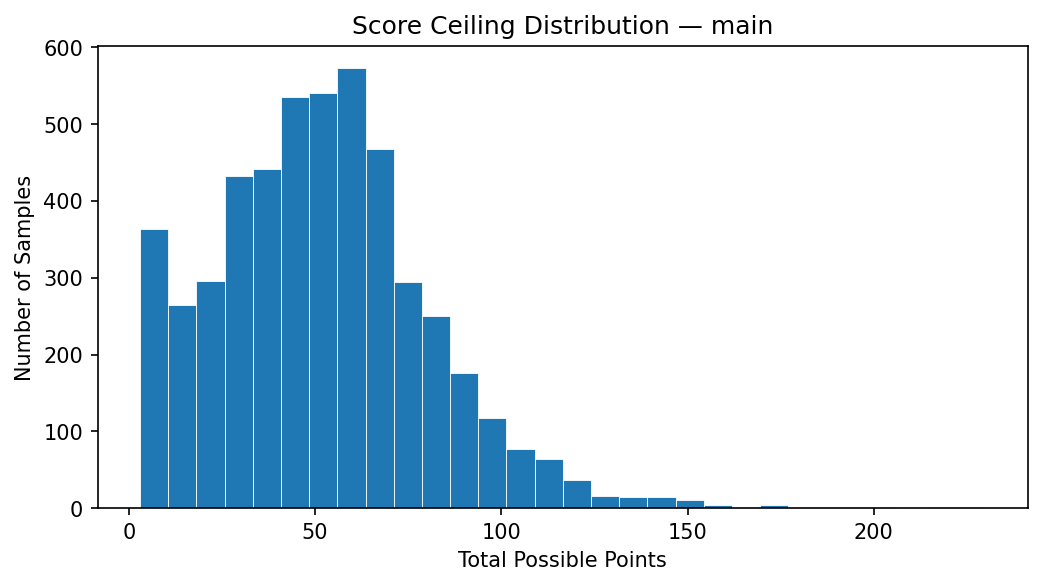

score_ceiling_distribution — hard


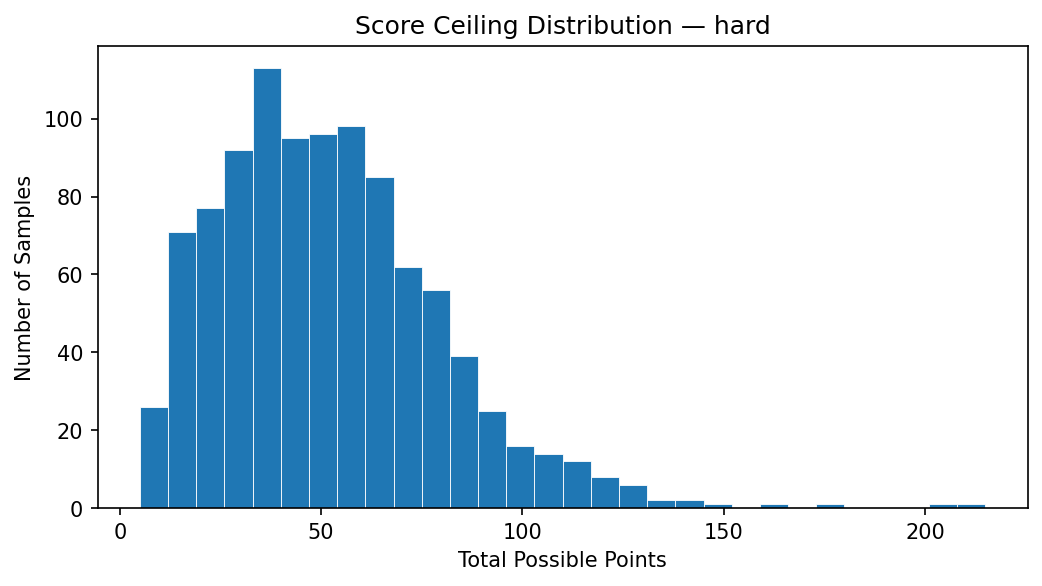

score_ceiling_distribution — consensus


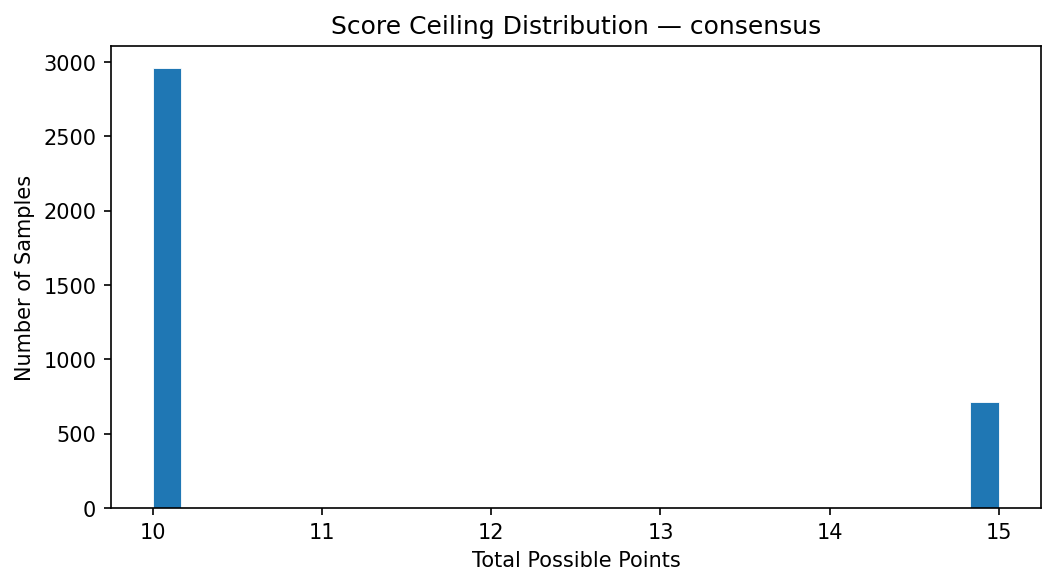

theme_axis_heatmap — main


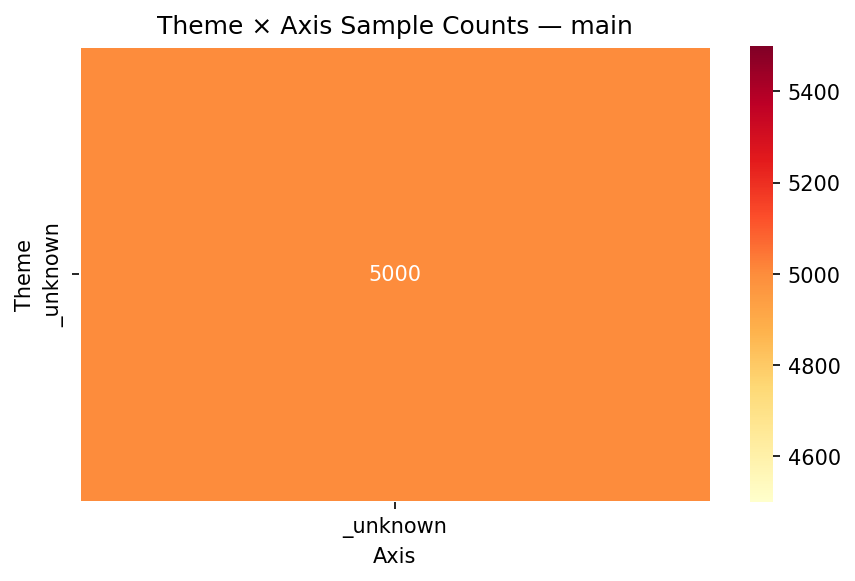

theme_axis_heatmap — hard


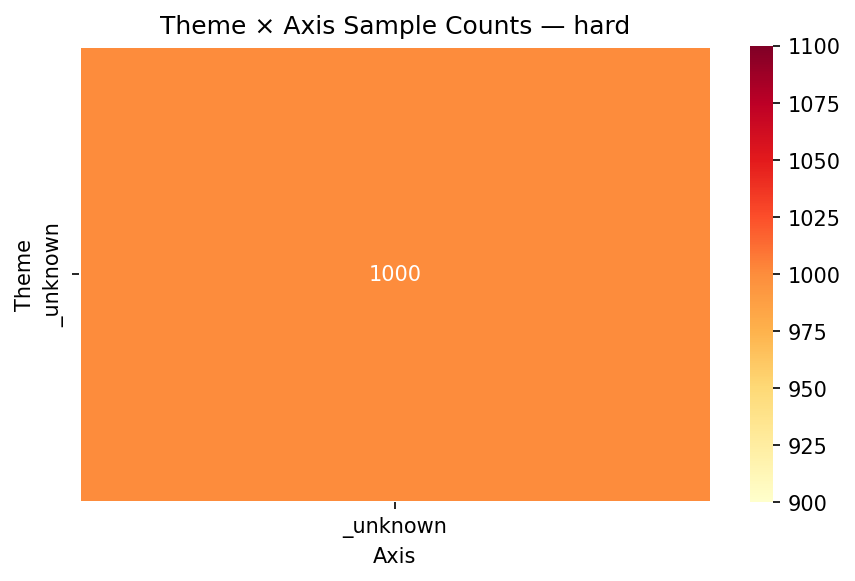

theme_axis_heatmap — consensus


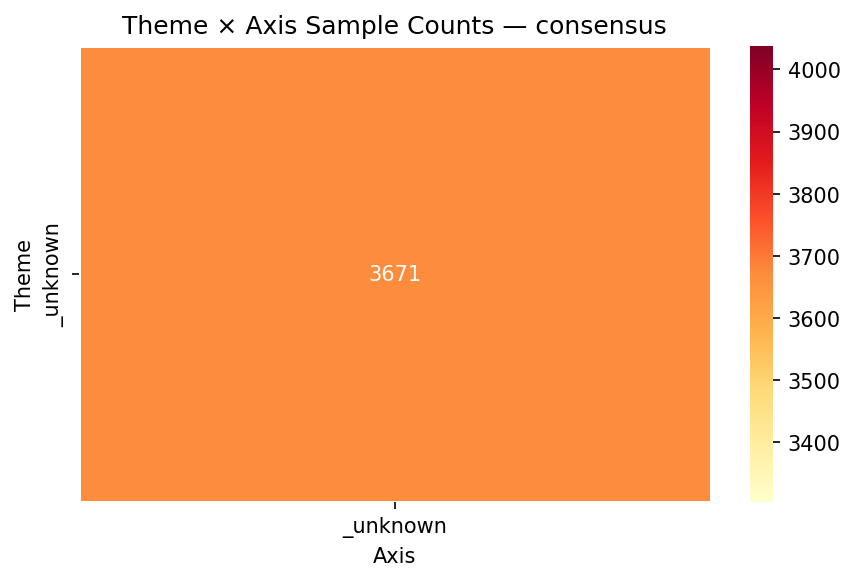

criteria_weight_histogram — main


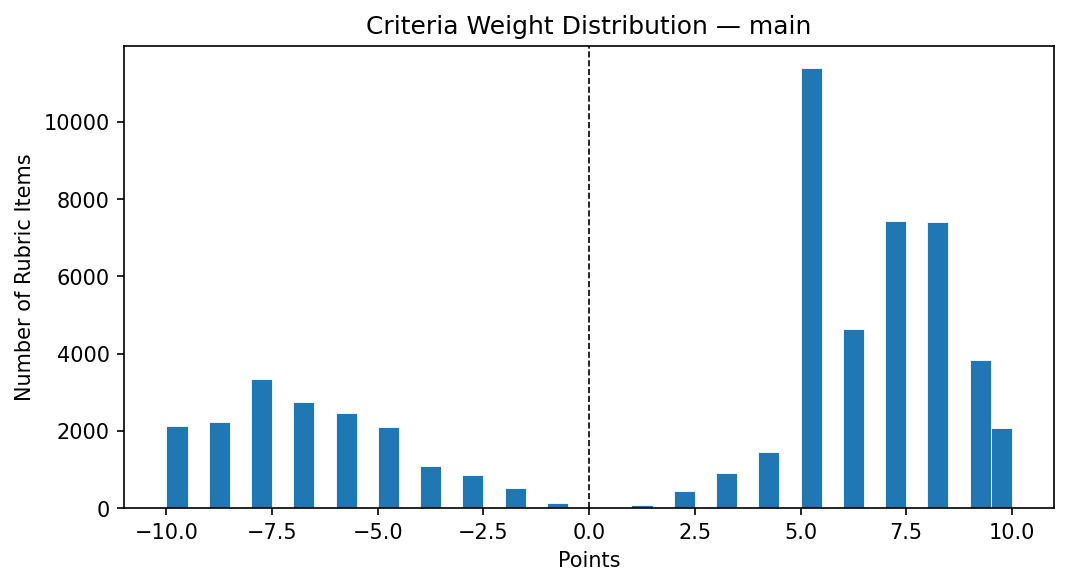

criteria_weight_histogram — hard


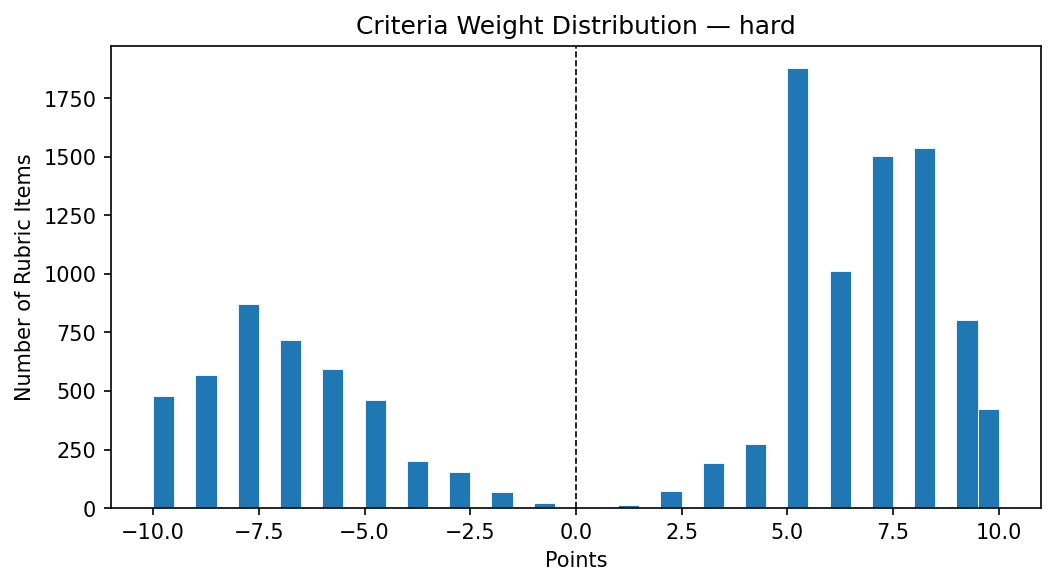

criteria_weight_histogram — consensus


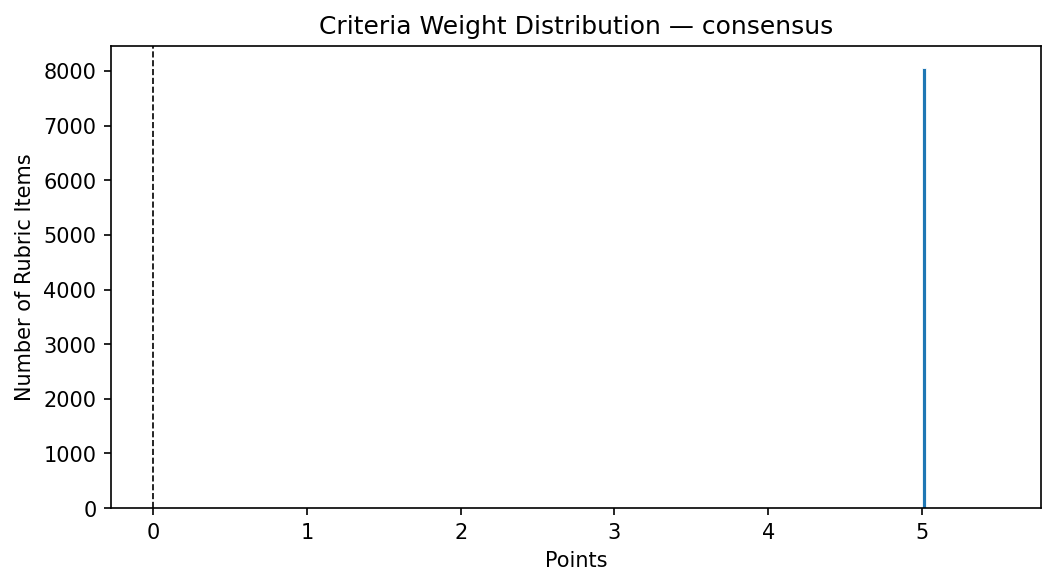

In [26]:
viz_results = run_category("visualization", datasets, OUTPUT_DIR, save=True)

for name, subset_results in viz_results.items():
    for subset, stats in subset_results.items():
        if stats and "paths" in stats:
            for path in stats["paths"]:
                print(f"{name} — {subset}")
                display(Image(path, width=700))

### 6.2 Penalty Heatmap (theme × axis)

Where do agents lose the most points? Each cell shows the **mean penalty per rubric item** at the intersection of a theme and an evaluation axis. Hot cells are the highest-risk intersections that tools and prompts must prioritize.

In [ ]:
result = run_one("penalty_heatmap", datasets, OUTPUT_DIR, save=True)["penalty_heatmap"]

for subset, stats in result.items():
    if not stats:
        continue
    if "paths" in stats:
        for path in stats["paths"]:
            print(f"\n{subset}")
            display(Image(path, width=700))
    # Show the raw table too
    df = pd.DataFrame(stats["penalty_table"]).T.fillna(0)
    display(df.style.background_gradient(cmap="Reds", axis=None).format("{:.1f}"))

### 6.3 Single-Turn vs Multi-Turn Complexity

Do multi-turn conversations carry heavier rubrics? Box plots compare **rubric size**, **total possible points**, and **penalty mass ratio** between single-turn (1 user message) and multi-turn (>1) prompts. A rightward shift in multi-turn means the agent must invest more in context tracking.

In [ ]:
result = run_one("multiturn_complexity_comparison", datasets, OUTPUT_DIR, save=True)[
    "multiturn_complexity_comparison"
]

for subset, stats in result.items():
    if not stats:
        continue
    if "paths" in stats:
        single_n = stats["single_turn_count"]
        multi_n = stats["multi_turn_count"]
        print(f"\n{subset} \u2014 single_turn={single_n}, multi_turn={multi_n}")
        for path in stats["paths"]:
            display(Image(path, width=800))

    # Summary table
    rows = []
    for turn_type in ["single_turn", "multi_turn"]:
        if stats.get(turn_type):
            rows.append(
                {
                    "type": turn_type,
                    "mean_rubric_size": round(stats[turn_type]["rubric_size"]["mean"], 2),
                    "mean_possible_pts": round(
                        stats[turn_type]["total_possible_points"]["mean"], 2
                    ),
                    "mean_penalty_ratio": round(stats[turn_type]["penalty_mass_ratio"]["mean"], 3),
                }
            )
    display(pd.DataFrame(rows).set_index("type"))

### 6.4 Penalty Ratio CDF (main vs hard overlay)

At what threshold does penalty mass start dominating? The CDF shows the **cumulative fraction of samples** below each penalty_mass_ratio value. The vertical dashed line at 1.0 marks where penalty equals positive points — samples to its right have more downside than upside. The gap between main and hard curves quantifies how much harder the hard subset punishes mistakes.

In [ ]:
result = run_one("penalty_ratio_cdf", datasets, OUTPUT_DIR, save=True)["penalty_ratio_cdf"]

if "overlay" in result:
    if "paths" in result["overlay"]:
        display(Image(result["overlay"]["paths"][0], width=700))

    # Show key percentiles
    rows = []
    for subset, stats in result["overlay"]["per_subset"].items():
        rows.append(
            {
                "subset": subset,
                "mean": round(stats["mean"], 3),
                "median": round(stats["50%"], 3),
                "p75": round(stats["75%"], 3),
                "p95": round(stats["95%"], 3),
                "max": round(stats["max"], 3),
            }
        )
    display(pd.DataFrame(rows).set_index("subset"))

### 6.5 Reward vs Penalty Balance by Axis (diverging bar chart)

For each axis, shows the fraction of total absolute point mass that is **positive** (right, steelblue) vs **penalty** (left, salmon). Axes where the penalty share is large represent the hardest scoring dimensions.

In [ ]:
result = run_one("positive_share_by_axis", datasets, OUTPUT_DIR, save=True)[
    "positive_share_by_axis"
]

for subset, stats in result.items():
    print(f"\n=== {subset} ===")
    if "paths" in stats:
        display(Image(stats["paths"][0], width=700))
    share = stats["positive_share"]
    display(
        pd.DataFrame(
            {
                "positive_share": share,
                "penalty_share": {k: round(1 - v, 4) for k, v in share.items()},
            }
        )
    )

### 6.6 Positive Share Heatmap (theme × axis)

A **RdYlGn** heatmap where each cell shows the positive-point share (0–1) for a given theme–axis combination. Green cells are reward-heavy; red cells are penalty-heavy.

In [ ]:
result = run_one("positive_share_heatmap", datasets, OUTPUT_DIR, save=True)[
    "positive_share_heatmap"
]

for subset, stats in result.items():
    print(f"\n=== {subset} ===")
    if "paths" in stats:
        display(Image(stats["paths"][0], width=700))
    print("\nPivot table (positive share):")
    display(pd.DataFrame(stats["pivot"]))

---
## 7. Actionable Insights for Agent Design

### Insight 1 — Accuracy is the universal penalty hotspot across all themes

The **penalty heatmap** reveals that `accuracy` carries the highest mean penalty per rubric item (7.0–7.8 points) in every theme, followed closely by `completeness` (6.3–8.2). This pattern is consistent across both `main` and `hard` subsets and does not depend on theme — even "safe" themes like `communication` penalize accuracy errors at 7.5 points per item.

**Agent design implication:** Every agent architecture — baseline, tool-augmented, and multi-agent — must prioritize factual accuracy above all else. The `drug_reference()` tool should be invoked proactively on any medical claim, not just when the agent is uncertain. The Reviewer stage should treat unsupported factual assertions as the primary failure mode to catch.

### Insight 2 — Health-data-tasks carry the highest penalty ratio: agents must hedge aggressively on data-interpretation prompts

`score_ceiling_by_theme` shows **health_data_tasks** has the highest mean penalty ratio across both `main` (0.754) and `hard` (0.896). For every positive point available, there is nearly an equal or greater penalty mass. In contrast, themes like `communication` (0.374) and `emergency_referrals` (0.380) have much lower ratios.

**Agent design implication:** When the agent detects a data-interpretation task (lab values, dosage calculations, statistical claims), it should adopt a conservative strategy — qualify uncertain figures, cite normal ranges, and avoid fabricating numeric details. The `drug_reference()` tool is especially valuable here to ground responses in verified data rather than hallucination.

### Insight 3 — Emergency items affect 34% of samples and concentrate in context_seeking and global_health themes

`emergency_axis_profile` shows **1,695 of 5,000 main samples** (33.9%) contain at least one emergency-related rubric item, generating 6,335 penalty points. Emergency items are not confined to the `emergency_referrals` theme — they appear heavily in `global_health` (560 samples), `context_seeking` (433), and `emergency_referrals` (383).

**Agent design implication:** The `emergency_flag()` tool cannot rely on simple keyword triggers limited to obviously-emergency prompts. It must fire across diverse clinical contexts, including global-health questions (tropical diseases, travel medicine) and context-seeking conversations where the patient's situation may evolve toward urgency. A broad sensitivity with low false-negative rate is preferable to a narrow, precise trigger.

### Insight 4 — The hard subset is driven by penalty mass, not rubric complexity — the CDF confirms a shifted tail

`hard_subset_signature` shows rubric size (+0.40 items) and total possible points (-0.58) are nearly identical between hard and main, but **penalty_mass_ratio jumps by +0.147** (from 0.495 to 0.642). The **penalty ratio CDF** makes this concrete: at the p75 mark, main is at 0.605 while hard reaches 0.750; at p95, main hits 1.087 vs hard at 1.333. Roughly **25% of hard samples have penalty mass exceeding 75% of their positive mass**, compared to ~25% of main at just 60%.

**Agent design implication:** Hard samples are hard because wrong answers are punished more severely, not because the questions are more complex. The multi-agent pipeline's **Reviewer** stage is critical for hard samples: it should specifically check for claims that could trigger penalty criteria (unsupported diagnoses, missing safety caveats, overconfident language) rather than just verifying completeness. A penalty-ratio threshold near 0.75 could trigger enhanced Reviewer scrutiny.

### Insight 5 — Multi-turn conversations do NOT carry heavier rubrics, but still require context tracking

The **multiturn complexity comparison** shows a surprising result: single-turn and multi-turn prompts have nearly identical rubric complexity in `main` (rubric_size 11.40 vs 11.51, penalty_ratio 0.495 vs 0.495). In `hard`, multi-turn samples are actually slightly *less* penalized (0.629 vs 0.653). However, 42% of main and 48% of hard prompts are multi-turn, and the `context_awareness` axis — which rewards integration of prior turns — has the highest positive-to-penalty ratio (75% positive, 25% penalty).

**Agent design implication:** Multi-turn conversations don't need a heavier review process, but they absolutely need full context tracking. The Triage stage should pass complete conversation history to downstream specialists. The system prompt should explicitly instruct: "Consider all previous turns in the conversation when formulating your response." This is a low-risk, high-reward optimization since `context_awareness` has the most favorable scoring ratio of any axis.

### Insight 6 — communication_quality and instruction_following axes carry disproportionate penalty risk despite low weight

`rubric_axis_difficulty` shows **communication_quality** has the highest penalty fraction (37.5%) and lowest mean points (1.31), followed by **instruction_following** (36.5% penalty, 1.74 mean). The penalty heatmap confirms these axes are consistently the *least* penalized per item (4.2–6.3 points), but their high *frequency* of penalty items means cumulative losses add up.

**Agent design implication:** Prompt engineering should emphasize tone calibration and strict instruction adherence. The system prompt should include explicit directives: match the patient's language register, respect format constraints (lists vs paragraphs, length limits), and avoid unsolicited additions. These "style" failures are penalized almost as often as factual errors but are easier to prevent with good prompting.